In [1]:
import torch
import numpy as np
import pandas as pd
import time
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    TrainerCallback
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [2]:
train_df = pd.read_csv("../data/processed/train_all_versions.csv")
val_df   = pd.read_csv("../data/processed/val_all_versions.csv")
test_df  = pd.read_csv("../data/processed/test_all_versions.csv")

binary_mapping = {
    "very_negative": 0,
    "negative": 0,
    "neutral": 0,
    "positive": 1,
    "very_positive": 1
}

for df in [train_df, val_df, test_df]:
    df["label"] = df["sentiment"].map(binary_mapping)
    df.dropna(subset=["text_dl", "label"], inplace=True)

print("Train samples:", len(train_df))
print("Val samples:", len(val_df))
print("Test samples:", len(test_df))


Train samples: 155469
Val samples: 19437
Test samples: 19434


Tokenizer replaces padding and vocab

In [ ]:
max_len = 150

# Transformers require subword tokenization, pretrained vocabulary alignment so we take the pre trained model for this

tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

train_encodings = tokenizer(train_df["text_dl"].astype(str).tolist(),
                            truncation=True, padding=True, max_length=max_len)

val_encodings = tokenizer(val_df["text_dl"].astype(str).tolist(),
                          truncation=True, padding=True, max_length=max_len)

test_encodings = tokenizer(test_df["text_dl"].astype(str).tolist(),
                           truncation=True, padding=True, max_length=max_len)


d:\bilstm_clean_env\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Dataset class 

Trainer expects PyTorch Dataset object.

It converts:

- input_ids

- attention_mask

- labels

into tensors.

Without this → Trainer cannot batch data.

In [4]:
class SentimentDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.values

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = SentimentDataset(train_encodings, train_df["label"])
val_dataset   = SentimentDataset(val_encodings, val_df["label"])
test_dataset  = SentimentDataset(test_encodings, test_df["label"])


Our data is imbalanced so we use class weights

In [5]:
class_counts = train_df["label"].value_counts().sort_index()
total = sum(class_counts)
weights = [total / (2 * count) for count in class_counts]
class_weights = torch.tensor(weights).to(device)

print("Class Weights:", class_weights)


Class Weights: tensor([2.1234, 0.6540], device='cuda:0')


Load model 

In [6]:
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

model.to(device)


d:\bilstm_clean_env\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): MultiHeadSelfAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
 

CUstom trainer 

we are overwriting the default loss as hugging face loss doesnt handle class imbalance.
My custom loss applies class weights

In [7]:
from torch.nn import CrossEntropyLoss

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = CrossEntropyLoss(weight=class_weights)
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss


Metrics Function

In [8]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc}


In [9]:
class PrintMetricsCallback(TrainerCallback):
    def on_epoch_end(self, args, state, control, **kwargs):
        logs = state.log_history[-1]
        print(f"\nEpoch {int(state.epoch)}")
        print(f"Train Loss: {logs.get('loss', 'N/A')}")
        print(f"Val Loss: {logs.get('eval_loss', 'N/A')}")
        print(f"Val Accuracy: {logs.get('eval_accuracy', 'N/A')}")


Training Params

In [ ]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=4,
    per_device_train_batch_size=8, # Transformers are memory intensive. Can increase
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=4, # so the effective batch size is 32
    learning_rate=2e-5,
    weight_decay=0.01, # regularization to prevent overfitting, used in the original bert paper 
    warmup_ratio=0.1, # Its L2 regularization,controls learning rate scheduling, transformers are sensitive to this 
    fp16=True, # mixed precision for faster training on GPUs
    evaluation_strategy="epoch", 
    logging_strategy="steps",
    logging_steps=1000,
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss", # valdiation loss is used as metric to determine early stopping
    report_to="none"
)


In [11]:
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(early_stopping_patience=2),
        PrintMetricsCallback()
    ]
)


d:\bilstm_clean_env\Lib\site-packages\accelerate\accelerator.py:450: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


Train the model

In [12]:
start = time.time()
trainer.train()
end = time.time()

print(f"\nTraining time: {(end-start)/60:.2f} minutes")


  0%|          | 0/19432 [00:00<?, ?it/s]

{'loss': 0.4753, 'learning_rate': 1.0277777777777777e-05, 'epoch': 0.21}
{'loss': 0.3407, 'learning_rate': 1.9937099725526078e-05, 'epoch': 0.41}
{'loss': 0.3187, 'learning_rate': 1.8794602012808785e-05, 'epoch': 0.62}
{'loss': 0.308, 'learning_rate': 1.7650960658737423e-05, 'epoch': 0.82}

Epoch 0
Train Loss: 0.308
Val Loss: N/A
Val Accuracy: N/A


  0%|          | 0/2430 [00:00<?, ?it/s]

Checkpoint destination directory ./results\checkpoint-4858 already exists and is non-empty.Saving will proceed but saved results may be invalid.


{'eval_loss': 0.3052132725715637, 'eval_accuracy': 0.9039975304830993, 'eval_runtime': 26.5827, 'eval_samples_per_second': 731.191, 'eval_steps_per_second': 91.413, 'epoch': 1.0}
{'loss': 0.2871, 'learning_rate': 1.650846294602013e-05, 'epoch': 1.03}
{'loss': 0.2554, 'learning_rate': 1.5364821591948765e-05, 'epoch': 1.23}
{'loss': 0.2463, 'learning_rate': 1.4223467520585545e-05, 'epoch': 1.44}
{'loss': 0.2497, 'learning_rate': 1.3079826166514183e-05, 'epoch': 1.65}
{'loss': 0.2459, 'learning_rate': 1.193618481244282e-05, 'epoch': 1.85}

Epoch 2
Train Loss: 0.2459
Val Loss: N/A
Val Accuracy: N/A


...

{'eval_loss': 0.2672213912010193, 'eval_accuracy': 0.893090497504759, 'eval_runtime': 27.5731, 'eval_samples_per_second': 704.925, 'eval_steps_per_second': 88.129, 'epoch': 2.0}
{'loss': 0.23, 'learning_rate': 1.0793687099725526e-05, 'epoch': 2.06}
{'loss': 0.1917, 'learning_rate': 9.650045745654165e-06, 'epoch': 2.26}
{'loss': 0.1928, 'learning_rate': 8.5064043915828e-06, 'epoch': 2.47}
{'loss': 0.198, 'learning_rate': 7.363906678865509e-06, 'epoch': 2.68}
{'loss': 0.1949, 'learning_rate': 6.220265324794145e-06, 'epoch': 2.88}

Epoch 2
Train Loss: 0.1949
Val Loss: N/A
Val Accuracy: N/A


  0%|          | 0/2430 [00:00<?, ?it/s]

{'eval_loss': 0.3073955774307251, 'eval_accuracy': 0.9030714616453156, 'eval_runtime': 26.3846, 'eval_samples_per_second': 736.679, 'eval_steps_per_second': 92.099, 'epoch': 3.0}
{'loss': 0.1707, 'learning_rate': 5.0789112534309245e-06, 'epoch': 3.09}
{'loss': 0.153, 'learning_rate': 3.935269899359561e-06, 'epoch': 3.29}
{'loss': 0.1468, 'learning_rate': 2.791628545288198e-06, 'epoch': 3.5}
{'loss': 0.1519, 'learning_rate': 1.6479871912168347e-06, 'epoch': 3.7}
{'loss': 0.1466, 'learning_rate': 5.054894784995426e-07, 'epoch': 3.91}

Epoch 3
Train Loss: 0.1466
Val Loss: N/A
Val Accuracy: N/A


  0%|          | 0/2430 [00:00<?, ?it/s]

{'eval_loss': 0.3652811348438263, 'eval_accuracy': 0.9045120131707568, 'eval_runtime': 26.2864, 'eval_samples_per_second': 739.432, 'eval_steps_per_second': 92.443, 'epoch': 4.0}
{'train_runtime': 3542.1268, 'train_samples_per_second': 175.566, 'train_steps_per_second': 5.486, 'train_loss': 0.23499305437699716, 'epoch': 4.0}

Training time: 59.04 minutes


Evaluation 


In [13]:
logs = pd.DataFrame(trainer.state.log_history)
logs = logs[logs["epoch"].notna()]

train_logs = logs[logs["loss"].notna()].copy()
eval_logs = logs[logs["eval_loss"].notna()].copy()

train_logs["epoch"] = train_logs["epoch"].round(2)
eval_logs["epoch"] = eval_logs["epoch"].round(2)


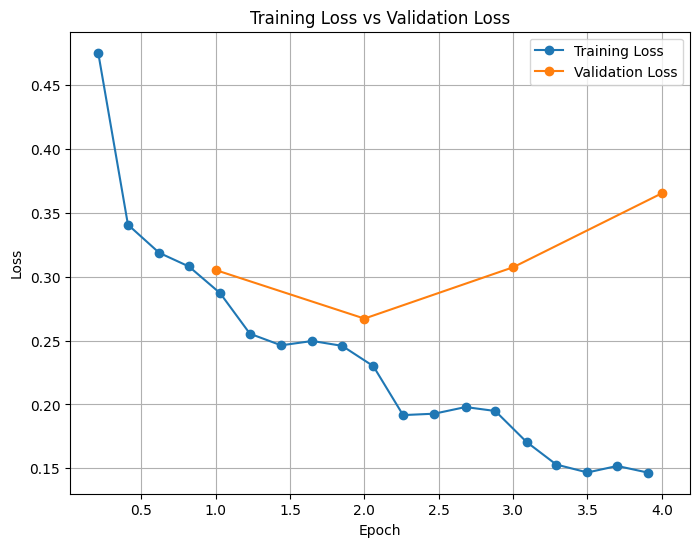

In [14]:
plt.figure(figsize=(8,6))

train_epoch_loss = train_logs.groupby("epoch")["loss"].mean().reset_index()

plt.plot(train_epoch_loss["epoch"], train_epoch_loss["loss"], marker='o', label="Training Loss")
plt.plot(eval_logs["epoch"], eval_logs["eval_loss"], marker='o', label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


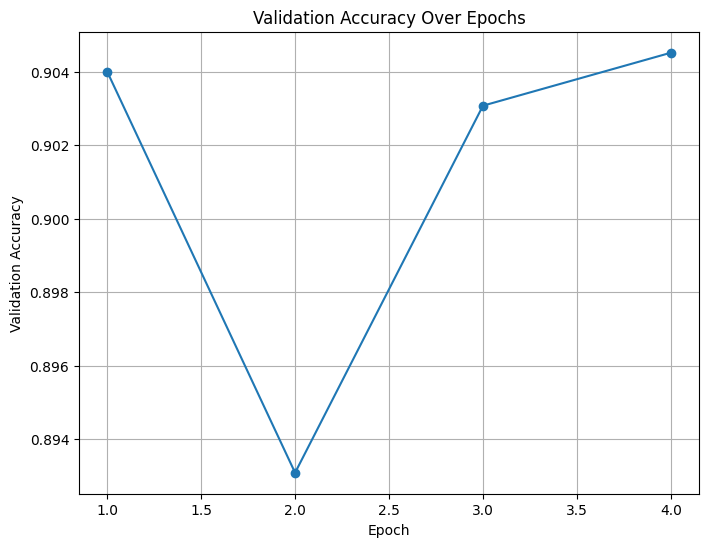

In [15]:
plt.figure(figsize=(8,6))

plt.plot(eval_logs["epoch"], eval_logs["eval_accuracy"], marker='o')

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Over Epochs")
plt.grid(True)
plt.show()


In [16]:
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)

print("Classification Report:\n")
print(classification_report(test_df["label"], y_pred))


  0%|          | 0/2430 [00:00<?, ?it/s]

Classification Report:

              precision    recall  f1-score   support

           0       0.71      0.88      0.79      4578
           1       0.96      0.89      0.92     14856

    accuracy                           0.89     19434
   macro avg       0.84      0.89      0.86     19434
weighted avg       0.90      0.89      0.89     19434



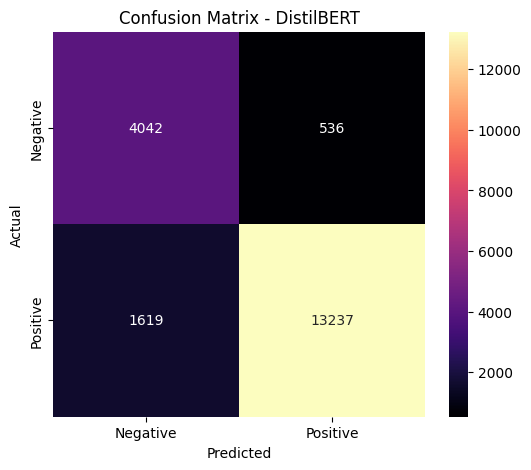

In [17]:
cm = confusion_matrix(test_df["label"], y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"],
            cmap="magma")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - DistilBERT")
plt.show()
